In [1]:
from baumeva import BinaryGA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
def fdm(k, C, L, n_int, T_w, t_f, h, T_inf):
    '''
    k: Condutividade térmica [W/(m °C)]
    C: Capacidade térmica volumétrica [J/(°C m^3)]
    L: Comprimento do domínio 1d [m]
    n_int: Número de nós internos
    T_w: Temperatura da extremidade oeste [°C]
        Obs: na outra extremidade (leste), é imposto fluxo nulo
    t_f: Tempo físico final da simulação [s]
    h: Coeficiente de pelicula [W/(m^2 °C)]
    T_inf: Temperatura do ambiente [°C]
    '''
    
    # Discretizacao dos domínios espacial e temporal
    n  = n_int + 2
    dx = L / (n_int + 1)
    dt = (dx ** 2) / (2.0 * (k / C)) # Critério de Fourier (1/2) para estabilidade
    nt = int(t_f / dt) + 1
    
    # Condicao inicial
    T = np.zeros(n) + T_inf
    
    # Vetores para armazenar os resultados
    t   = [] # Passos de tempo
    T_e = [] # Temperatura da extremidade leste
    T_t = [] # Temperatura em todos os nós (incluindo os fantasmas) no passo de tempo
    
    # Função auxiliar que calcula as derivadas espaciais para o RK4
    def calcular_derivadas(T_estado):
        # Cria uma cópia para não alterar a variável original acidentalmente
        T_temp = np.copy(T_estado)
        
        # Garante as condições de contorno no estado intermediário
        T_temp[0]  = 2 * T_w - T_temp[1]                                             # Condicao de Dirichlet na extremidade oeste
        T_temp[-1] = ((k / dx - h / 2) * T_temp[-2] + h * T_inf) / (k / dx + h / 2)  # Condicao de Robin na extremidade leste
        
        dTdt = np.zeros(n)
        # Diferenças finitas centralizadas vetorizadas
        dTdt[1:-1] = (k / C) * (T_temp[2:] - 2*T_temp[1:-1] + T_temp[:-2]) / (dx ** 2)
        
        return dTdt

    for i in range(nt):
        # Coeficientes do RK4
        k1 = calcular_derivadas(T)
        k2 = calcular_derivadas(T + 0.5 * dt * k1)
        k3 = calcular_derivadas(T + 0.5 * dt * k2)
        k4 = calcular_derivadas(T + dt * k3)
        
        # Marcha no tempo
        T = T + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        
        # Reforça as condicoes de contorno
        T[0] = 2 * T_w - T[1]                                              # Condicao de Dirichlet na extremidade oeste
        T[-1] = ((k / dx - h / 2) * T[-2] + h * T_inf) / (k / dx + h / 2)  # Condicao de Robin na extremidade leste
        
        t.append(i * dt)                 # Salva o passo de tempo
        T_e.append((T[-1] + T[-2]) / 2)  # Mede a temperatura da extremidade e salva
        T_t.append(T)                    # Salva a temperatura em todos os nós do passo de tempo
        
    return [np.array(t), np.array(T_e), np.array(T_t)]

In [3]:
# Define a função de custo
def f(X):
    # Calcula o resultado numérico para o individuo (T_ni)
    T_ni = fdm(k=X[0], C=X[1], L=L, n_int=n_int, T_w=T_w, t_f=t_f, h=h, T_inf=T_inf)
    # Gera um vetor numerico T_ni com dimensao igual ao dado "experimental"
    T_ri = np.interp(T_ni[0], data['t'].values, data['Temperatura'].values)
    # Retorna o valor da funcao de custo
    return np.sum((T_ri - T_ni[1])**2)

In [4]:
# Importa os dados "experimentais"
data = pd.read_csv('data.csv')

In [5]:
# Define os parâmetros para o FDM
L     = 0.0254 # Comprimento do domínio 1d [m]
n_int = 30     # Número de nós internos
T_w   = 100    # Temperatura da extremidade oeste [°C]
t_f   = 120    # Tempo físico final da simulação [s]
h     = 10     # Coeficiente de pelicula [W/(m^2 °C)]
T_inf = 25     # Temperatura do ambiente [°C]

In [6]:
# Configuração do GA
binary_ga = BinaryGA(num_generations=100,                      # Numero de gerações
                     num_individ=20,                           # Numero de individuos em cada geracao
                     gens=((1, 100, 0.01), (1e6, 5e6, 0.1)),   # Intervalo de busca das variáveis
                     obj_function=f,
                     obj_value=0,
                     is_gray=True,
                     mutation_lvl=0.35,
                     early_stop=None)

In [9]:
# Teste 1
inicio = time.perf_counter()
ga_data = binary_ga.optimize()
fim = time.perf_counter()
tempo_total = fim - inicio
print(f"Tempo: {tempo_total:.6f} segundos")

|=====================================================================================|
Index generation: 99
Best solution:
	index generation: 70
	genotype: ['0', '1', '0', '0', '1', '0', '0', '0', '1', '0', '0', '1', '0', '1', '1', '1', '1', '1', '0', '1', '1', '0', '1', '0', '1', '1', '0', '1', '0', '0', '0', '0', '1', '0', '0', '1', '1', '1', '0', '0']
	phenotype: [44.659586156381614, 3575697.460408471]
	fitness score: 0.0013327489735904992
	objective score: 749.3288464788271
	feasible region: True
Tempo: 554.794241 segundos


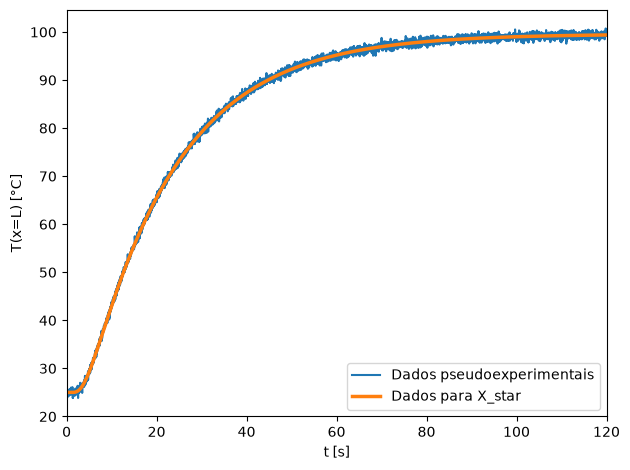

In [10]:
X_star = ga_data.best_solution['phenotype']           # Obtem o vetor com a melhor solucao
best = fdm(k=X_star[0], C=X_star[1], L=L, n_int=n_int, T_w=T_w, t_f=t_f, h=h, T_inf=T_inf)

plt.figure()

plt.plot(data['t'], data['Temperatura'], label='Dados pseudoexperimentais')
plt.plot(best[0], best[1], label='Dados para X_star', lw=2.5)

plt.xlabel('t [s]');
plt.ylabel('T(x=L) [°C]');
plt.xlim(0, 120)
plt.legend()
plt.tight_layout()